# Customer Churn Prediction — End-to-End ML Pipeline
Goal: Predict if a customer will churn (1) or not (0)

## 1. Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load dataset — path is relative to notebook location inside /notebooks/
df = pd.read_csv('../data/churn.csv')

print('Shape:', df.shape)
df.head()

Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('Column names:', df.columns.tolist())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Column names: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Data types:
 customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Missing values:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Basic statistics:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Exploratory Data Analysis (EDA)

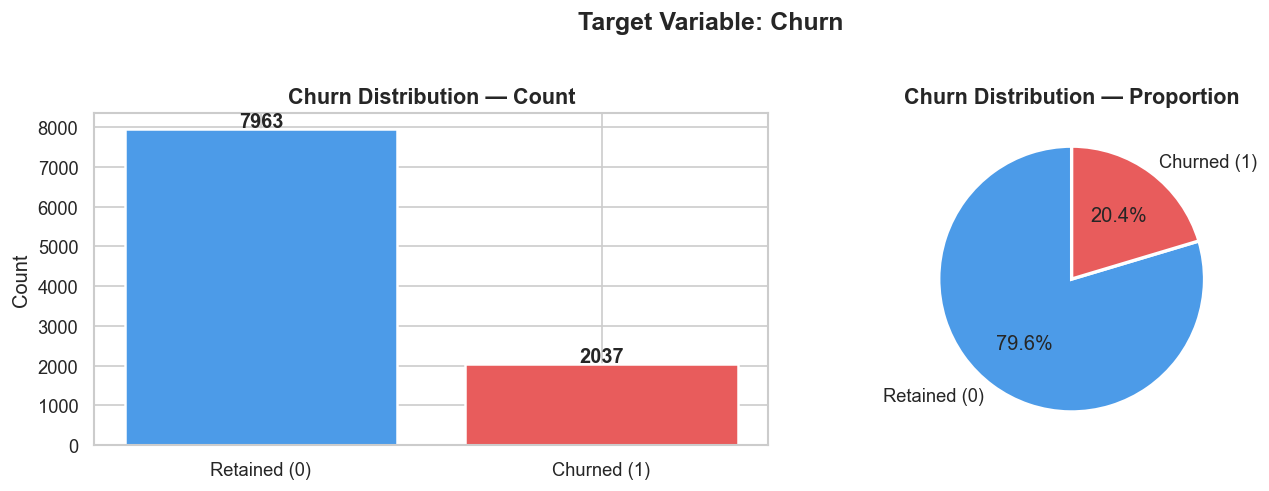

In [4]:
# --- Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=['#4C9BE8', '#E85C5C'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.1f%%', colors=['#4C9BE8', '#E85C5C'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/eda_churn_distribution.png', bbox_inches='tight')
plt.show()

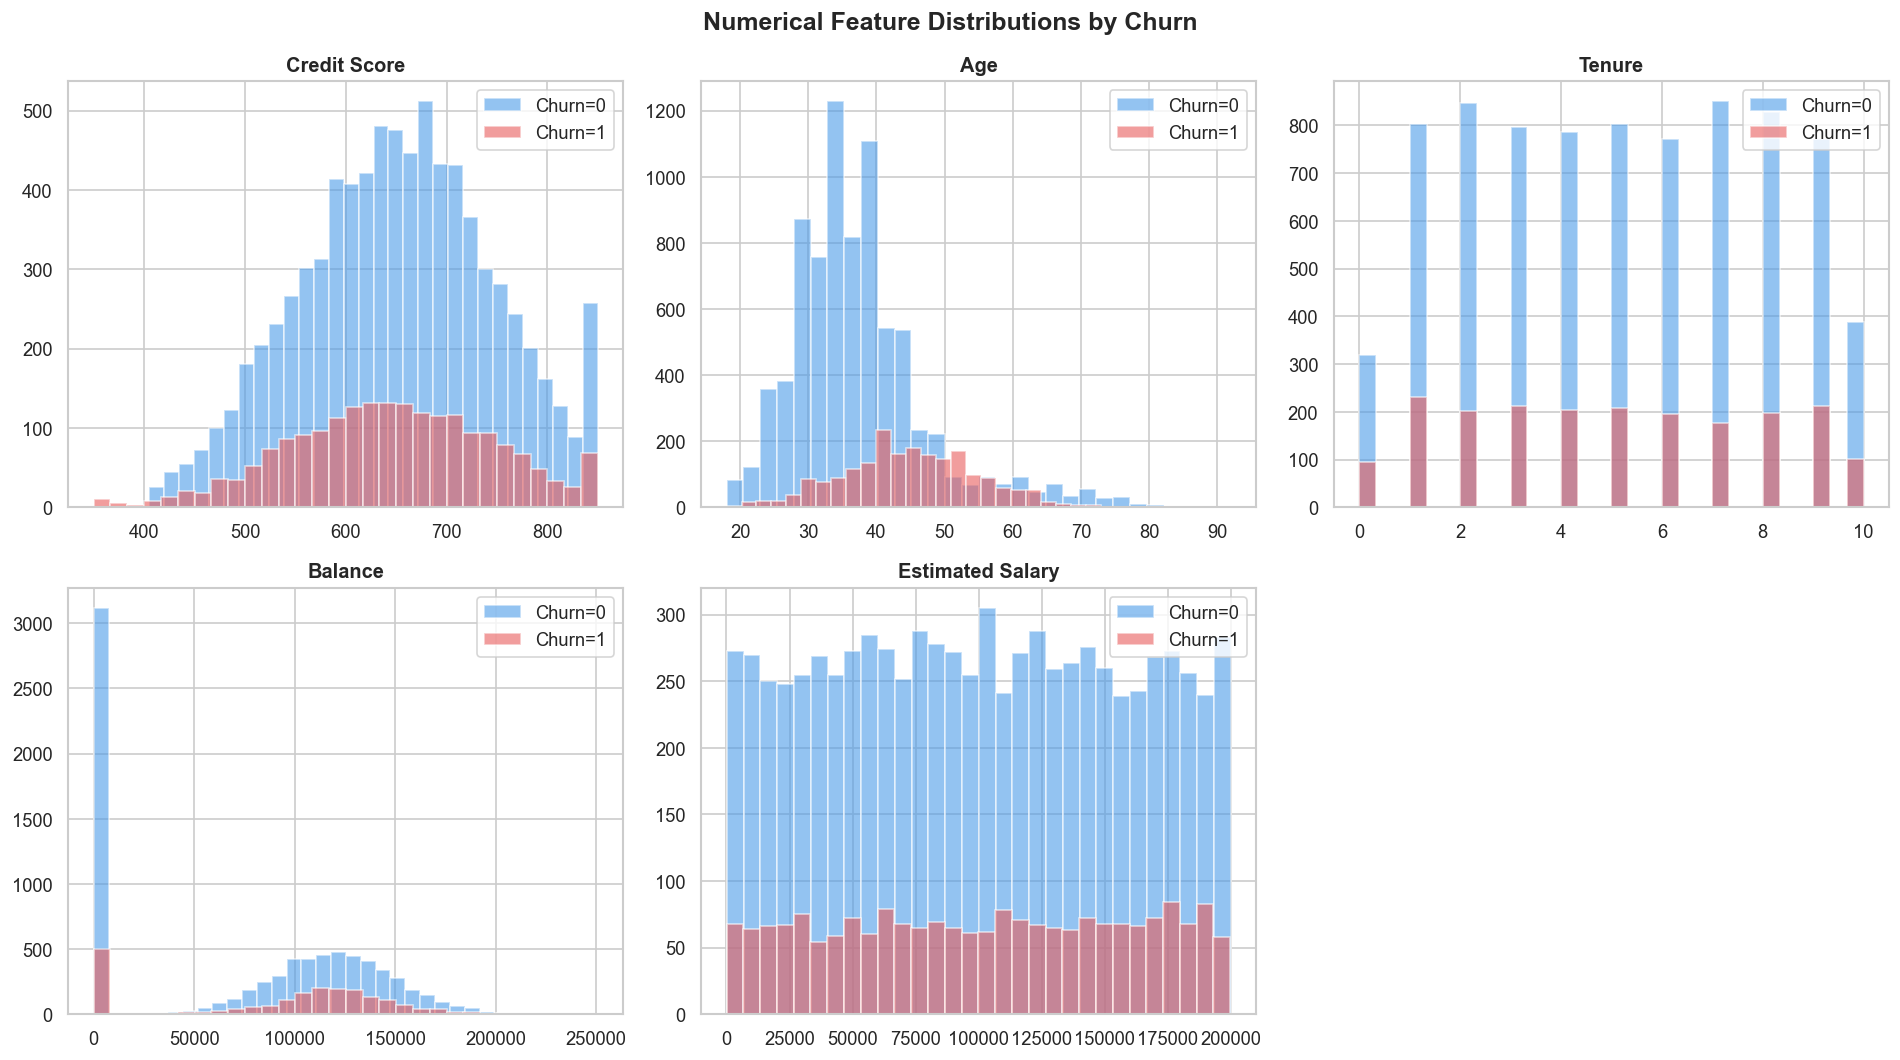

In [5]:
# --- Numerical Feature Distributions ---
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [(0, '#4C9BE8'), (1, '#E85C5C')]:
        axes[i].hist(df[df['churn'] == label][col], bins=30, alpha=0.6,
                     color=color, label=f'Churn={label}', edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend()

axes[-1].axis('off')  # hide last unused subplot
plt.suptitle('Numerical Feature Distributions by Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_num_distributions.png', bbox_inches='tight')
plt.show()

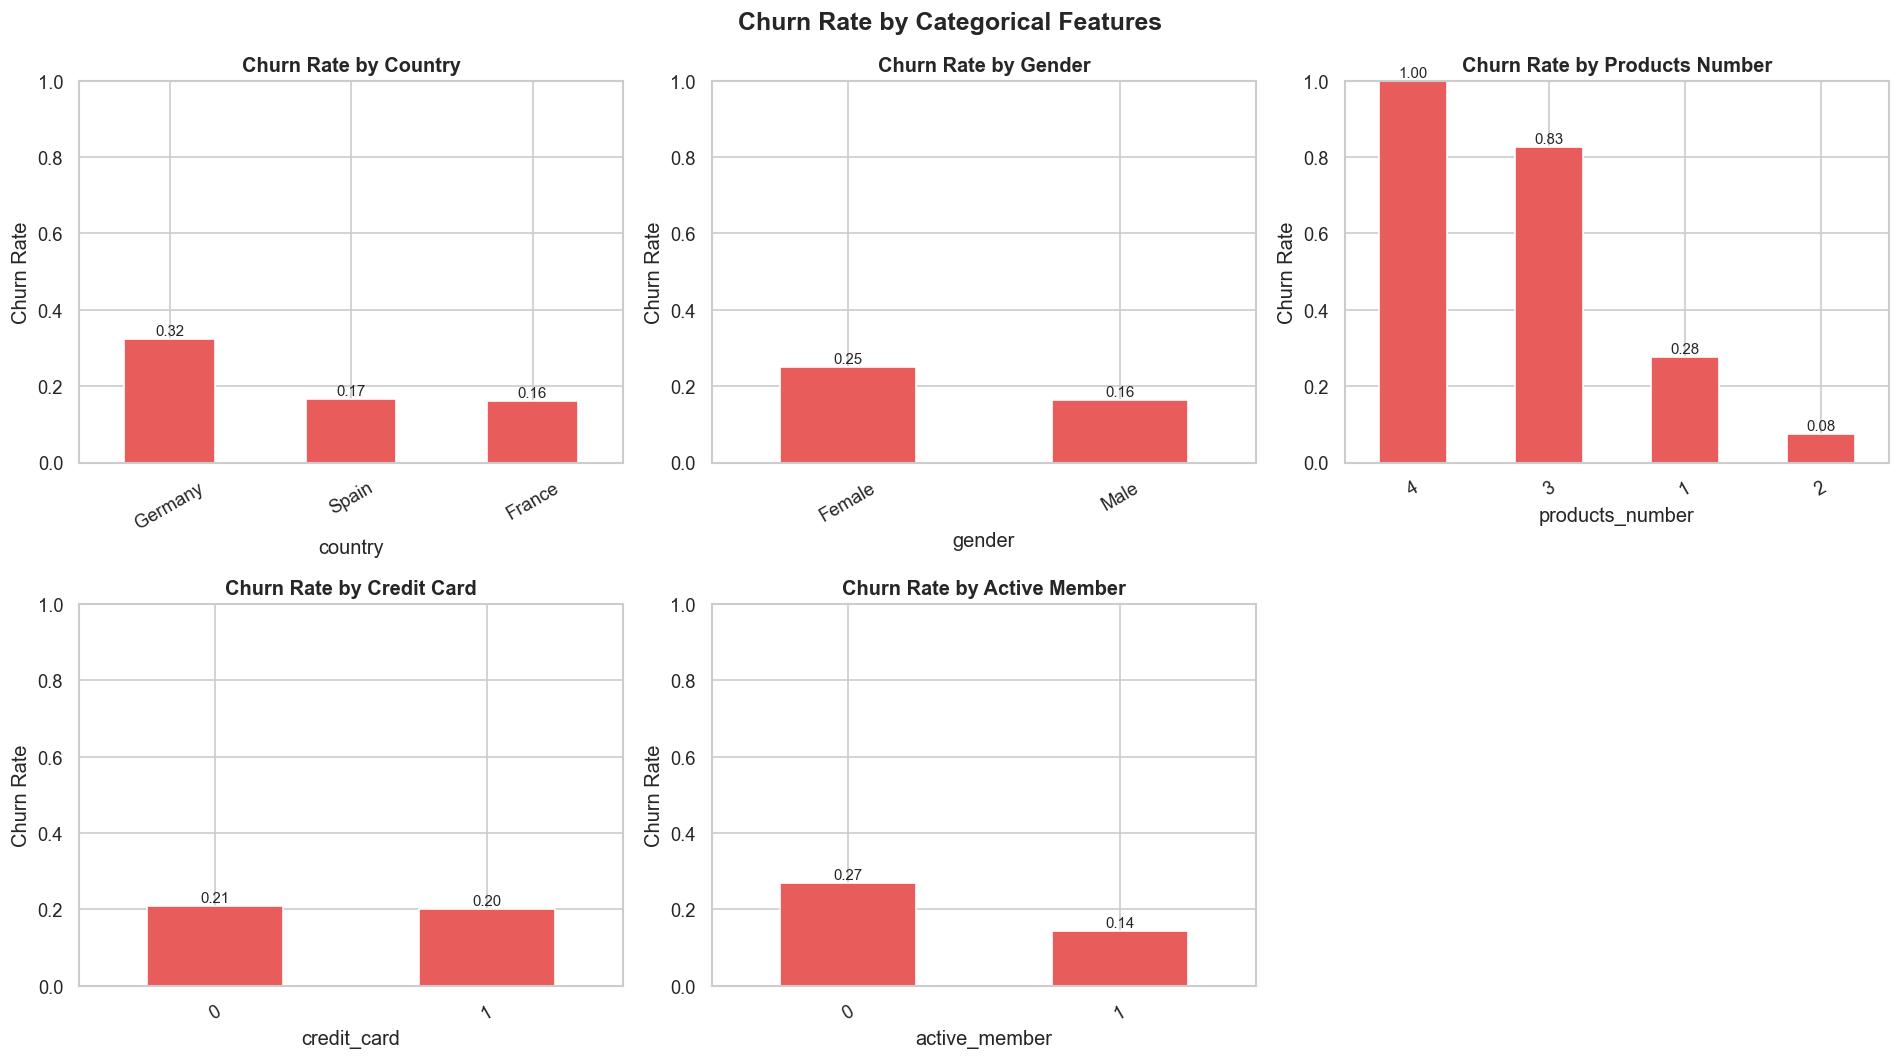

In [6]:
# --- Categorical Feature Analysis ---
cat_cols = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#E85C5C', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col.replace("_"," ").title()}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}',
                     ha='center', fontsize=9)

axes[-1].axis('off')
plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_cat_churnrate.png', bbox_inches='tight')
plt.show()

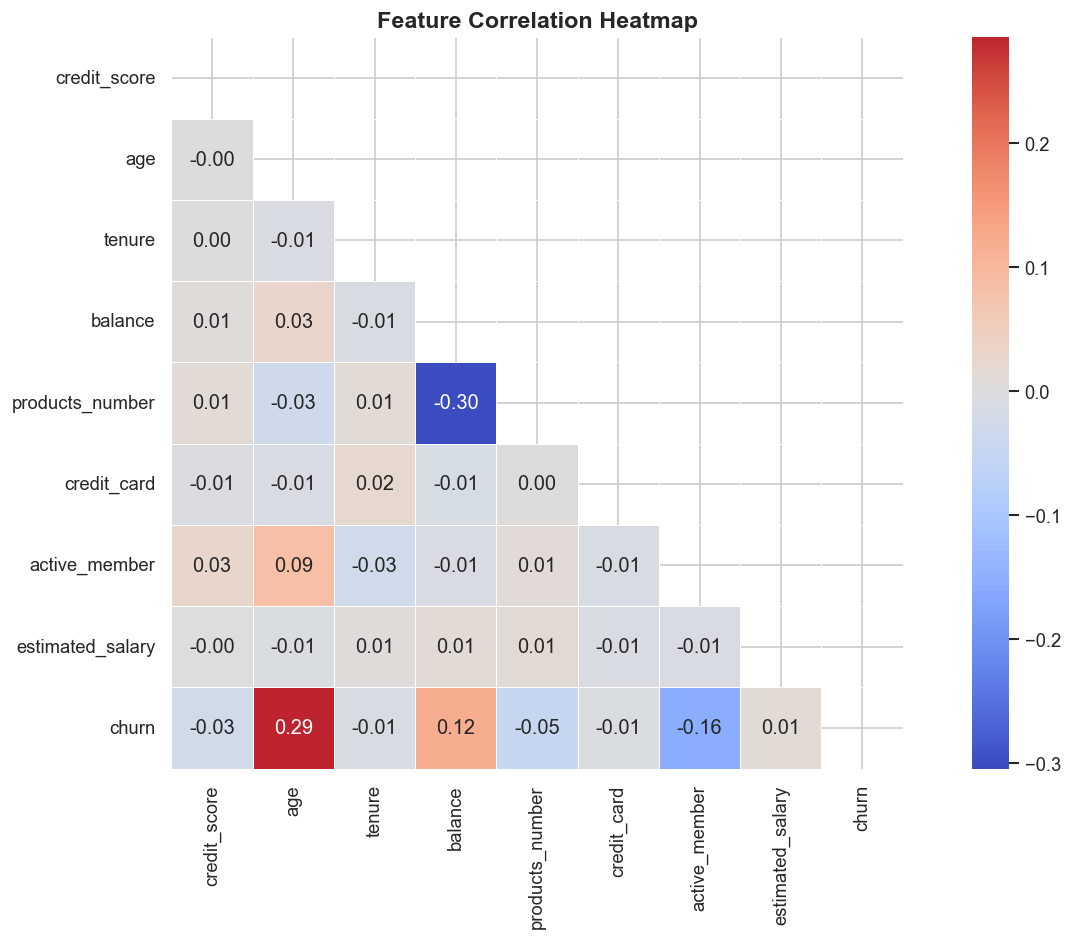

In [7]:
# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['customer_id']).select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

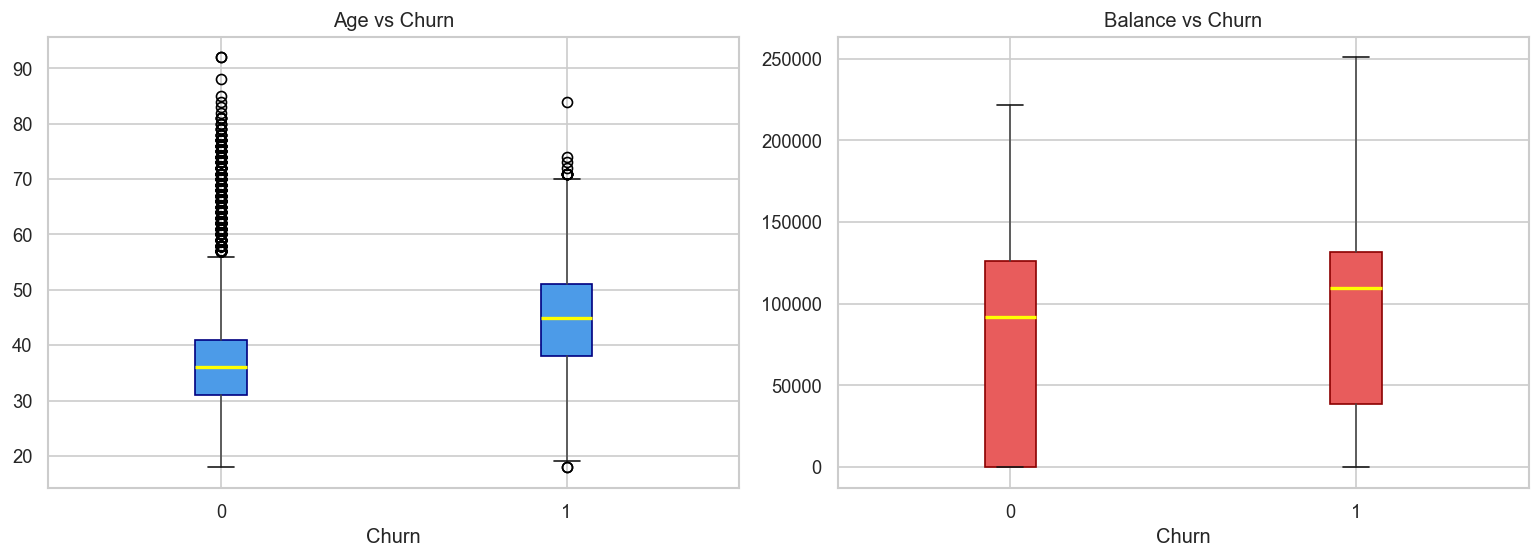

In [8]:
# --- Box Plots: Age and Balance vs Churn ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column='age', by='churn', ax=axes[0], patch_artist=True,
           boxprops=dict(facecolor='#4C9BE8', color='navy'),
           medianprops=dict(color='yellow', linewidth=2))
axes[0].set_title('Age vs Churn')
axes[0].set_xlabel('Churn')

df.boxplot(column='balance', by='churn', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#E85C5C', color='darkred'),
           medianprops=dict(color='yellow', linewidth=2))
axes[1].set_title('Balance vs Churn')
axes[1].set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../models/eda_boxplots.png', bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [9]:
# Step 1: Drop customer_id — it's an identifier, not a feature
df = df.drop(columns=['customer_id'])

# Step 2: Separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

print('Feature shape:', X.shape)
print('Target shape:', y.shape)
print('Class distribution:\n', y.value_counts())

Feature shape: (10000, 10)
Target shape: (10000,)
Class distribution:
 churn
0    7963
1    2037
Name: count, dtype: int64


In [10]:
# Step 3: Label Encode 'gender' (Binary: Male/Female → 0/1)
le = LabelEncoder()
X['gender'] = le.fit_transform(X['gender'])

print('Gender encoding mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Save label encoder for use during prediction
joblib.dump(le, '../models/label_encoder_gender.pkl')
print('Label encoder saved.')

Gender encoding mapping: {'Female': 0, 'Male': 1}
Label encoder saved.


In [11]:
# Step 4: OneHotEncode 'country' (Multi-class: France/Germany/Spain)
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' avoids dummy variable trap
country_encoded = ohe.fit_transform(X[['country']])
country_cols = ohe.get_feature_names_out(['country'])

# Create a DataFrame from encoded columns
country_df = pd.DataFrame(country_encoded, columns=country_cols, index=X.index)

# Drop original 'country' and add encoded columns
X = X.drop(columns=['country'])
X = pd.concat([X, country_df], axis=1)

print('OneHot encoded columns:', country_cols.tolist())
print('New X shape:', X.shape)

# Save OneHot encoder
joblib.dump(ohe, '../models/onehot_encoder_country.pkl')
print('OneHot encoder saved.')

OneHot encoded columns: ['country_Germany', 'country_Spain']
New X shape: (10000, 11)
OneHot encoder saved.


In [12]:
# Step 5: Train-Test Split BEFORE scaling (to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}, Test set: {X_test.shape}')
print(f'Train class distribution:\n{y_train.value_counts()}')

Training set: (8000, 11), Test set: (2000, 11)
Train class distribution:
churn
0    6370
1    1630
Name: count, dtype: int64


In [13]:
# Step 6: Scale numerical features (fit ONLY on training data)
num_features = ['credit_score', 'age', 'tenure', 'balance',
                'products_number', 'estimated_salary']

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])  # Use fit from train only!

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')
print('Scaler saved. Feature means:', scaler.mean_.round(2))

Scaler saved. Feature means: [6.507500e+02 3.895000e+01 5.020000e+00 7.638121e+04 1.530000e+00
 9.973081e+04]


In [14]:
# Step 7: Handle Class Imbalance using SMOTE (on training data only)
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())
print('SMOTE training shape:', X_train_sm.shape)

Before SMOTE: {0: 6370, 1: 1630}
After SMOTE: {1: 6370, 0: 6370}
SMOTE training shape: (12740, 11)


## 5. Model Training & Comparison

In [15]:
# Define all 4 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05,
                                         max_depth=5, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

# Store results
results = []
trained_models = {}

for name, model in models.items():
    print(f'Training: {name}...')
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df = results_df.set_index('Model').round(4)
print('\n--- Model Comparison ---')
results_df

Training: Logistic Regression...
Training: Decision Tree...
Training: Random Forest...


Training: XGBoost...

--- Model Comparison ---


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.8495,0.6256,0.6486,0.6369,0.8703
Random Forest,0.8460,0.6292,0.5921,0.6101,0.8473
Decision Tree,0.7675,0.4576,0.7690,0.5738,0.8390
Logistic Regression,0.7210,0.3932,0.6830,0.4991,0.7718


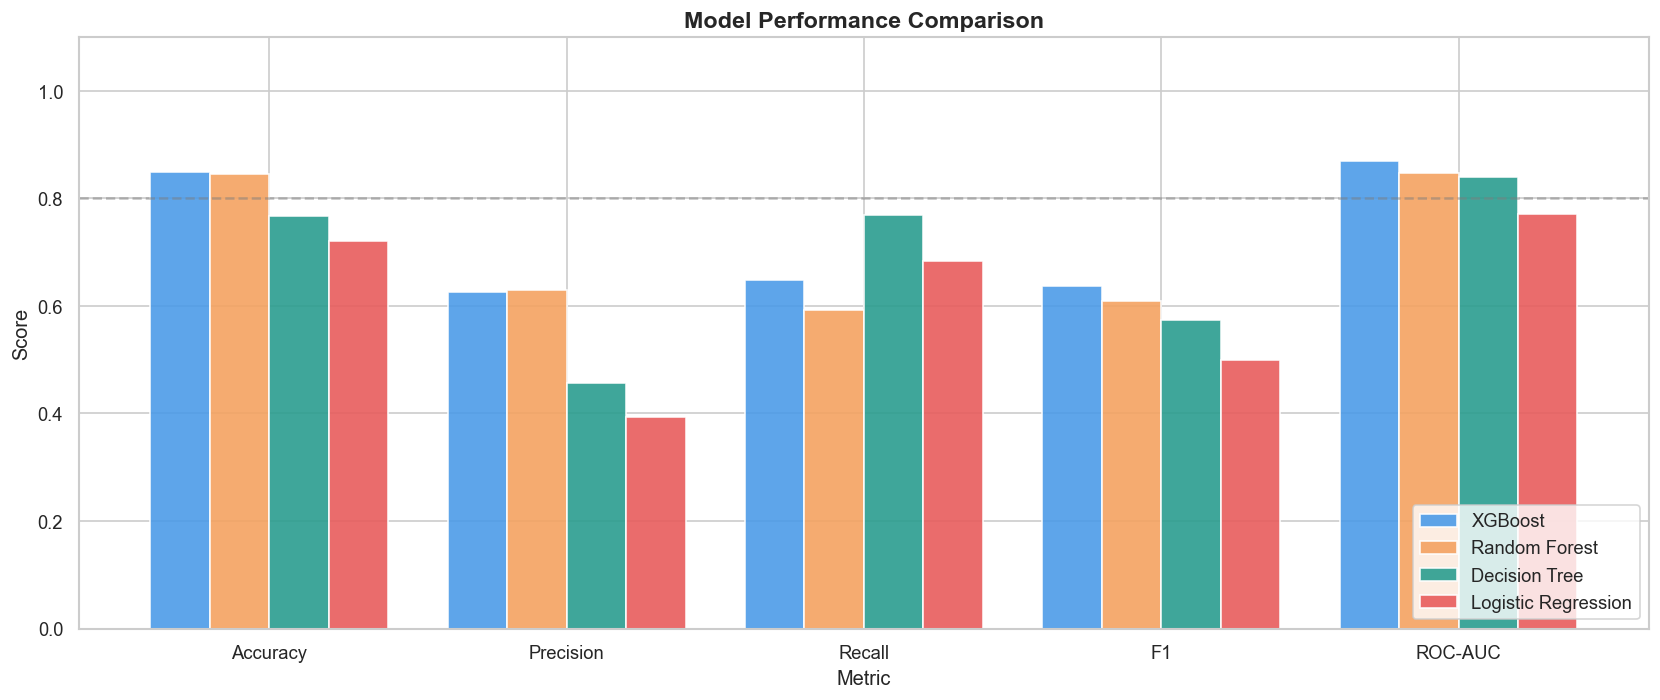

In [16]:
# --- Model Comparison Bar Chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#4C9BE8', '#F4A261', '#2A9D8F', '#E85C5C']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, row[metrics].values, width, label=model_name,
           color=colors[i], edgecolor='white', alpha=0.9)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')

plt.tight_layout()
plt.savefig('../models/model_comparison.png', bbox_inches='tight')
plt.show()

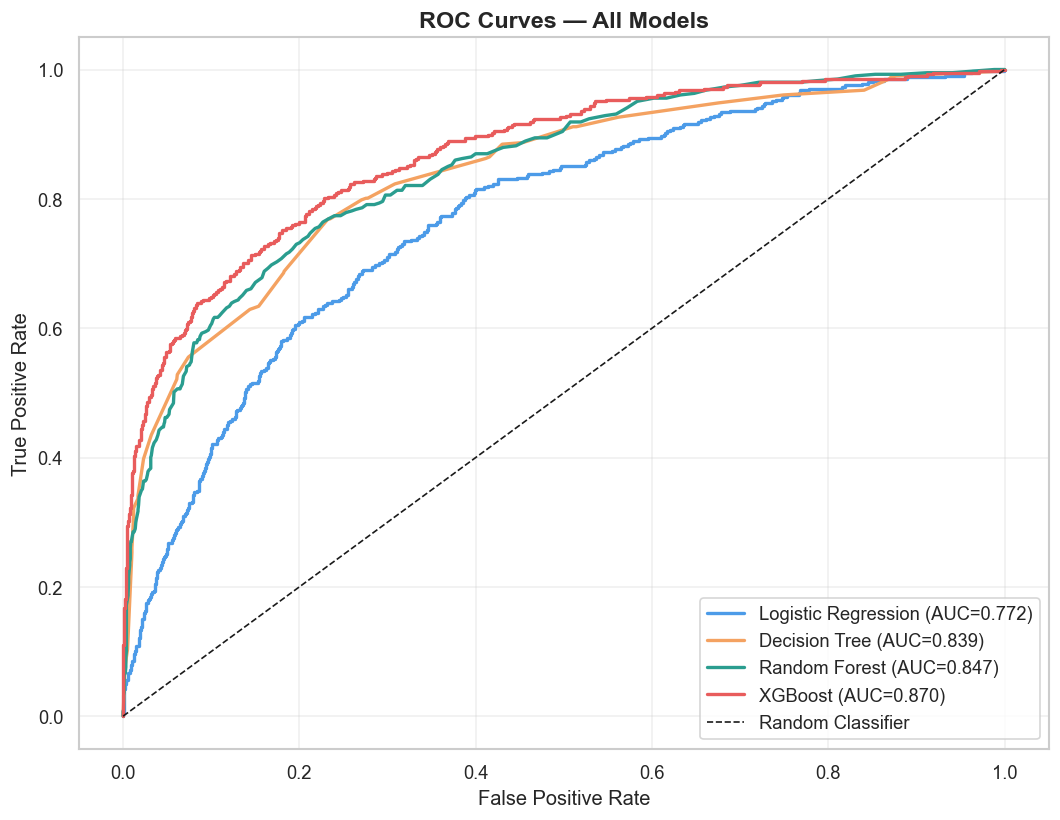

In [17]:
# --- ROC Curves for all models ---
plt.figure(figsize=(9, 7))

for i, (name, model) in enumerate(trained_models.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[i], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/roc_curves.png', bbox_inches='tight')
plt.show()

## 6. Model Selection

In [18]:
# Select best model based on ROC-AUC (most business-relevant for imbalanced classification)
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]

print(f'Best Model: {best_model_name}')
print(results_df.loc[best_model_name])

print("""
Business Reasoning for Model Selection:
- ROC-AUC is the primary metric because churn datasets are imbalanced.
- A high AUC means the model distinguishes churners from non-churners well,
  regardless of the decision threshold.
- Recall is also important: missing a churner (False Negative) costs more
  than flagging a retained customer (False Positive).
- XGBoost and Random Forest typically win due to ensemble learning.
""")

Best Model: XGBoost
Accuracy     0.8495
Precision    0.6256
Recall       0.6486
F1           0.6369
ROC-AUC      0.8703
Name: XGBoost, dtype: float64

Business Reasoning for Model Selection:
- ROC-AUC is the primary metric because churn datasets are imbalanced.
- A high AUC means the model distinguishes churners from non-churners well,
  regardless of the decision threshold.
- Recall is also important: missing a churner (False Negative) costs more
  than flagging a retained customer (False Positive).
- XGBoost and Random Forest typically win due to ensemble learning.



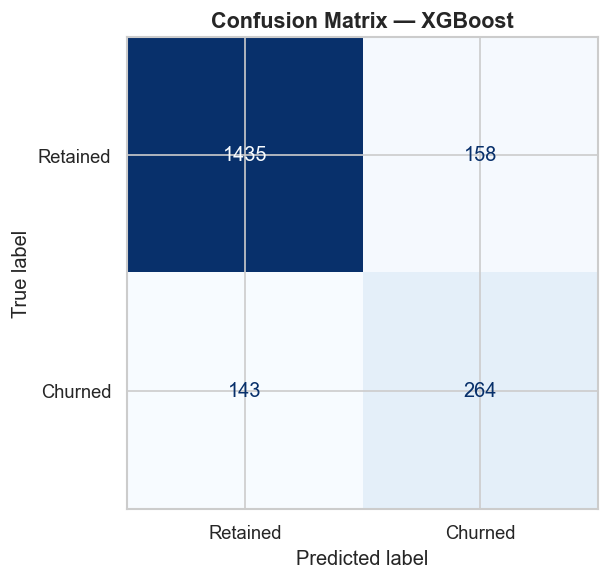

In [19]:
# --- Confusion Matrix for Best Model ---
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 7. Feature Importance

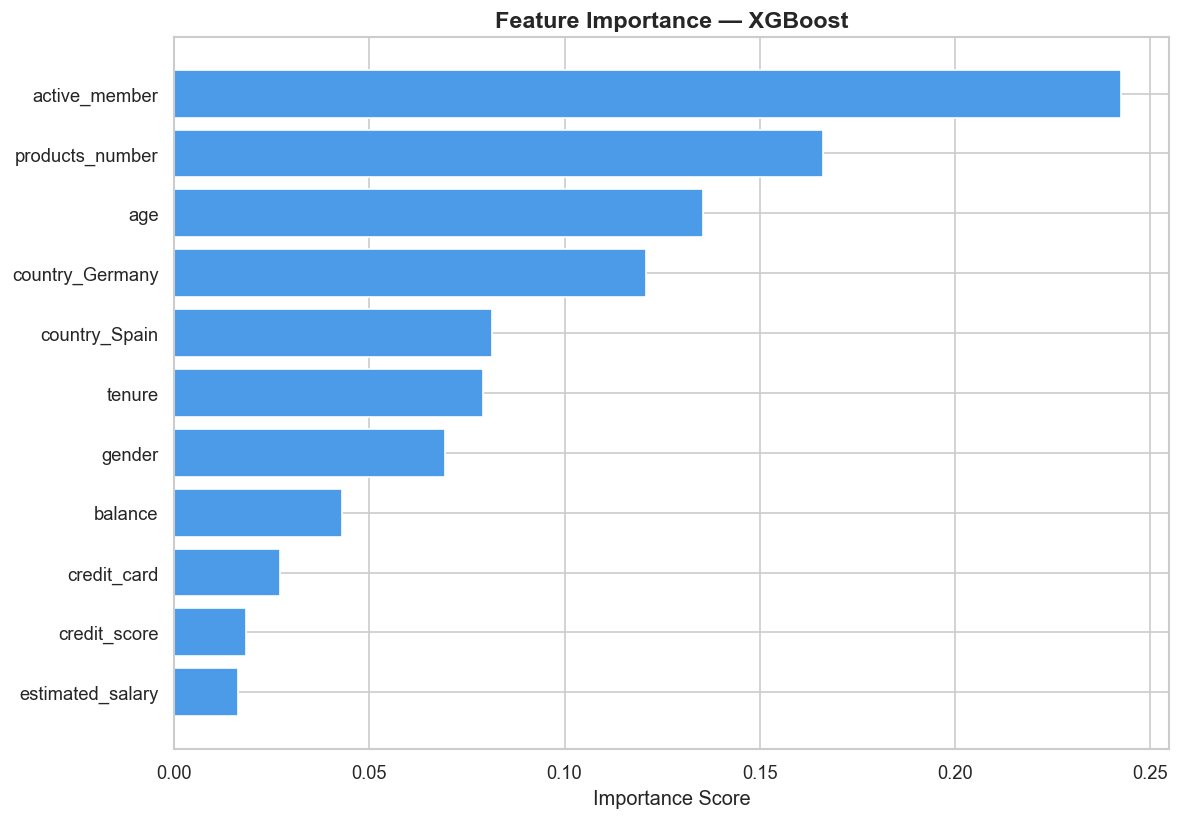

In [20]:
# Feature importance (works for tree-based models)
feature_names = X_train.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    # For Logistic Regression — use absolute coefficients
    importances = np.abs(best_model.coef_[0])

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

# Save feature importance for Streamlit app
feat_df.to_csv('../models/feature_importance.csv', index=False)

plt.figure(figsize=(10, 7))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='#4C9BE8', edgecolor='white')
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Save Model Artifacts

In [21]:
# Save best model
joblib.dump(best_model, '../models/model.pkl')
print(f'Best model saved: {best_model_name}')

# Save feature column order (critical for correct prediction alignment)
joblib.dump(X_train.columns.tolist(), '../models/feature_columns.pkl')
print('Feature columns saved:', X_train.columns.tolist())

# Save model results for dashboard
results_df.reset_index().to_csv('../models/model_results.csv', index=False)
print('Model results saved.')

print('\n--- All artifacts saved to /models/ ---')
print('  model.pkl')
print('  scaler.pkl')
print('  label_encoder_gender.pkl')
print('  onehot_encoder_country.pkl')
print('  feature_columns.pkl')
print('  feature_importance.csv')
print('  model_results.csv')
print('  (+ PNG visualizations)')

Best model saved: XGBoost
Feature columns saved: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain']
Model results saved.

--- All artifacts saved to /models/ ---
  model.pkl
  scaler.pkl
  label_encoder_gender.pkl
  onehot_encoder_country.pkl
  feature_columns.pkl
  feature_importance.csv
  model_results.csv
  (+ PNG visualizations)
